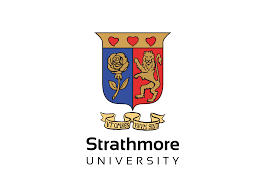

<p style="text-align: center;"><font size="5"> <font color = "blue"> Breast Cancer Detection|LogisticRegression </p>

<p style="text-align: center;"><font size="4">Samuel Irungu Kigotho</font></p>
<p style="text-align: center;"><font size="4">Adm No: 169124</font></p>
<p style="text-align: center;"><font size="4">Assigment: Regularization and SVM</font></p>
<p style="text-align: center;"><font size="4">DSA 8401: Applied Machine Learning</font></p>
<p style="text-align: center;"><font size="4">Master in Data Science and Analytic</font></p>


## Background information 

<p style='text-align: justify;'> This week’s activity focuses on studying the importance of regularization methods and practising with a new way of modelling data: Support Vectors Machines (SVM). <br>
The specific goals are: <br>
    • Practice the preprocessing of the data to get a suitable dataset. <br>
    • Study the generalization of the model when we use regularization techniques.<br>
    • Use and analyse SVM <p>  

# Assignment Description
In this activity we will work with the dataset called “Wisconsin Diagnostic Breast Cancer (WDBC)”,
which you can find at https://www.kaggle.com/uciml/breast-cancer-wisconsin-data.
It is requested:


In [147]:
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # plotting

# Load Data

In [148]:
url = "https://raw.githubusercontent.com/irungus/Applied-Machine-Learning/main/data.csv"
# Load the data into a pandas DataFrame
data = pd.read_csv(url)
# Display the first few rows of the dataset
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [149]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

**1. Import the dataset using Pandas. Do you have missing values? If so, what option have you
adopted to resolve it?**

In [150]:
data.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

There are no missing values in the dataset, there is a column called **"Unnamed:32"** which we are going to drop.

In [151]:
data=data.drop(columns="Unnamed: 32")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


**2. Now analyze the data and do the pre-processing that you consider appropriate. Here we are
asked to analyze the data incorporating medical knowledge to detect possible outliers, possible
incoherent values, etc. You can use seaborn’s pairplot function if you see fit (sns.pairplot()) to
tackle groups of variables in one go (although probably not the entire dataset at once).**


In [152]:
# Function to classify variables
def classify_and_print_variables(data):
    categorical = []
    binary = []
    nominal = []
    numerical = []

    for column in data.columns:
        if pd.api.types.is_numeric_dtype(data[column]):
            numerical.append(column)
        elif isinstance(data[column].dtype, pd.CategoricalDtype) or data[column].dtype == 'object':
            categorical.append(column)
            if data[column].nunique() == 2:
                binary.append(column)
            else:
                nominal.append(column)

    # Printing Categorical Variables
    print("Categorical Variables:")
    for i, var in enumerate(categorical, 1):
        print(f"{i}. {var}")

    # Printing Binary Variables
    print("\nBinary Variables:")
    if binary:
        for i, var in enumerate(binary, 1):
            print(f"{i}. {var}")
    else:
        print("None")

    # Printing Nominal Variables
    print("\nNominal Variables:")
    for i, var in enumerate(nominal, 1):
        print(f"{i}. {var}")

    # Printing Numerical Variables
    print("\nNumerical Variables:")
    for i, var in enumerate(numerical, 1):
        print(f"{i}. {var}")

# Run the function to classify and print variables
classify_and_print_variables(data)


Categorical Variables:
1. diagnosis

Binary Variables:
1. diagnosis

Nominal Variables:

Numerical Variables:
1. id
2. radius_mean
3. texture_mean
4. perimeter_mean
5. area_mean
6. smoothness_mean
7. compactness_mean
8. concavity_mean
9. concave points_mean
10. symmetry_mean
11. fractal_dimension_mean
12. radius_se
13. texture_se
14. perimeter_se
15. area_se
16. smoothness_se
17. compactness_se
18. concavity_se
19. concave points_se
20. symmetry_se
21. fractal_dimension_se
22. radius_worst
23. texture_worst
24. perimeter_worst
25. area_worst
26. smoothness_worst
27. compactness_worst
28. concavity_worst
29. concave points_worst
30. symmetry_worst
31. fractal_dimension_worst


In [153]:
data['diagnosis'] = data['diagnosis'].apply(lambda val:1 if val=='M' else 0)

In [154]:
numerical_summary = data.describe().transpose()

palette = sns.color_palette("viridis", as_cmap=True)

numerical_summary.style.background_gradient(cmap=palette)

,count,mean,std,min,25%,50%,75%,max
id,569.000000,30371831.432337,125020585.612224,8670.000000,869218.000000,906024.000000,8813129.000000,911320502.000000
diagnosis,569.000000,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200


# Outlier Detection 

Outliers in radius_mean:
82     25.22
108    22.27
122    24.25
164    23.27
180    27.22
202    23.29
212    28.11
236    23.21
339    23.51
352    25.73
369    22.01
461    27.42
503    23.09
521    24.63
Name: radius_mean, dtype: float64


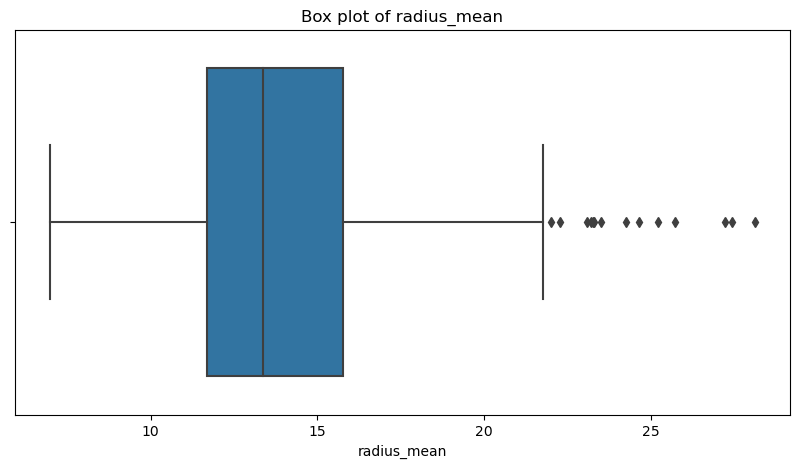

Outliers in texture_mean:
219    32.47
232    33.81
239    39.28
259    33.56
265    31.12
455    30.72
562    30.62
Name: texture_mean, dtype: float64


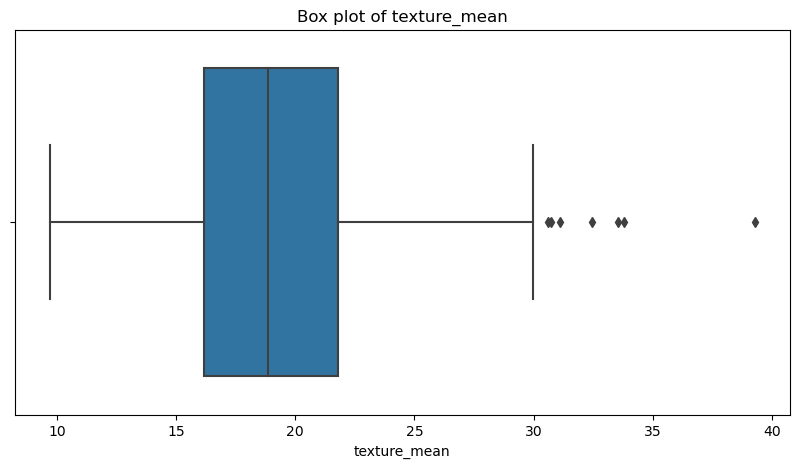

Outliers in perimeter_mean:
82     171.5
108    152.8
122    166.2
164    152.1
180    182.1
202    158.9
212    188.5
236    153.5
339    155.1
352    174.2
461    186.9
503    152.1
521    165.5
Name: perimeter_mean, dtype: float64


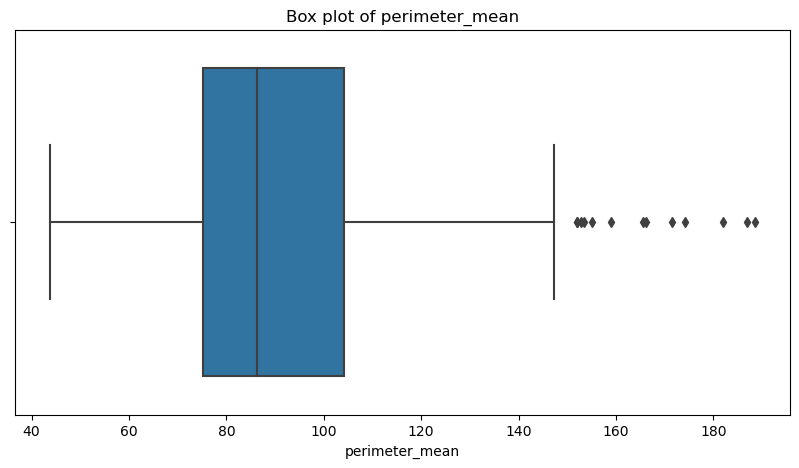

Outliers in area_mean:
23     1404.0
82     1878.0
108    1509.0
122    1761.0
164    1686.0
180    2250.0
202    1685.0
212    2499.0
236    1670.0
250    1364.0
265    1419.0
272    1491.0
339    1747.0
352    2010.0
368    1546.0
369    1482.0
372    1386.0
373    1335.0
393    1407.0
449    1384.0
461    2501.0
503    1682.0
521    1841.0
563    1347.0
564    1479.0
Name: area_mean, dtype: float64


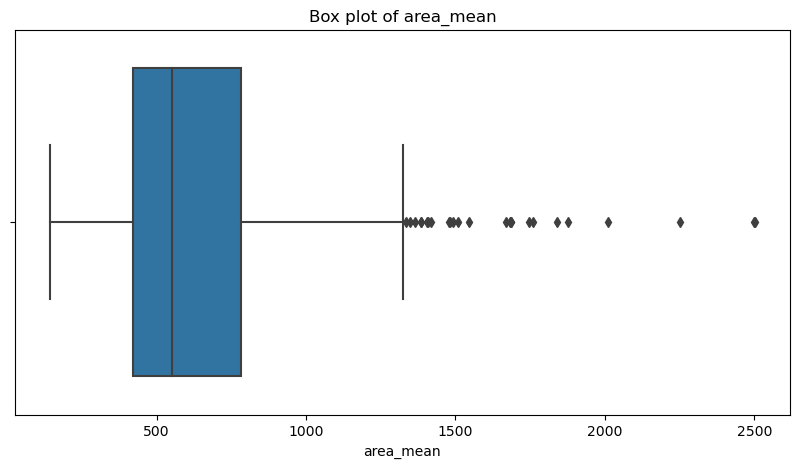

Outliers in smoothness_mean:
3      0.14250
105    0.13980
122    0.14470
504    0.16340
520    0.13710
568    0.05263
Name: smoothness_mean, dtype: float64


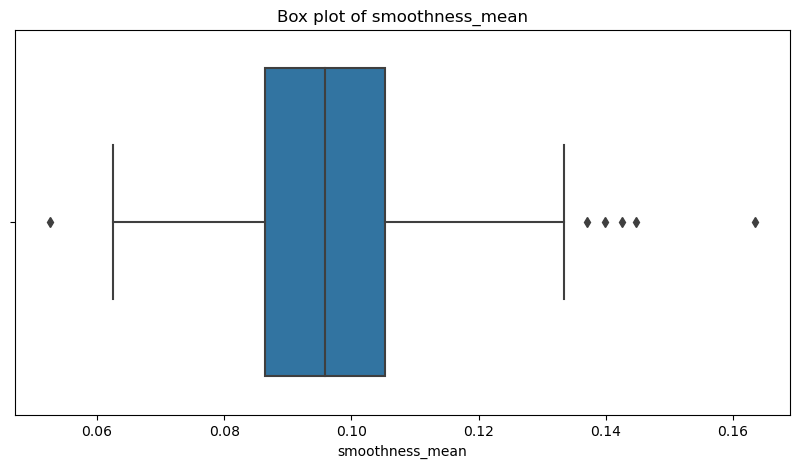

Outliers in compactness_mean:
0      0.2776
3      0.2839
9      0.2396
12     0.2458
14     0.2293
78     0.3454
82     0.2665
108    0.2768
122    0.2867
181    0.2832
190    0.2413
258    0.3114
351    0.2364
352    0.2363
400    0.2576
567    0.2770
Name: compactness_mean, dtype: float64


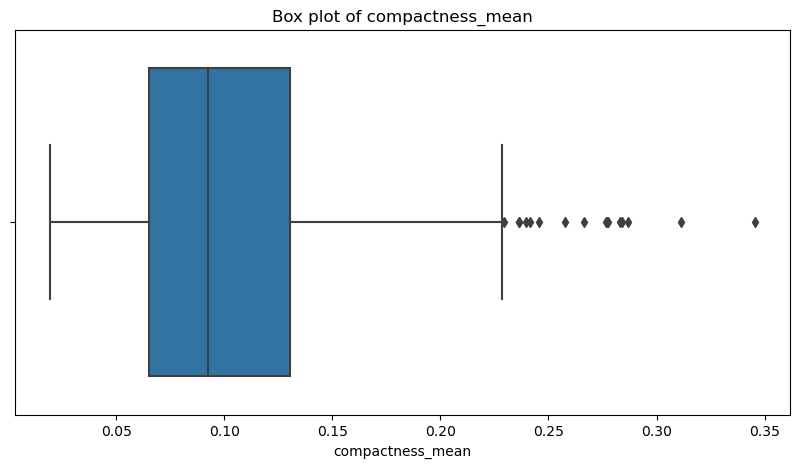

Outliers in concavity_mean:
0      0.3001
68     0.3130
78     0.3754
82     0.3339
108    0.4264
112    0.3003
122    0.4268
152    0.4108
180    0.2871
202    0.3523
212    0.3201
258    0.3176
351    0.2914
352    0.3368
400    0.3189
461    0.3635
563    0.3174
567    0.3514
Name: concavity_mean, dtype: float64


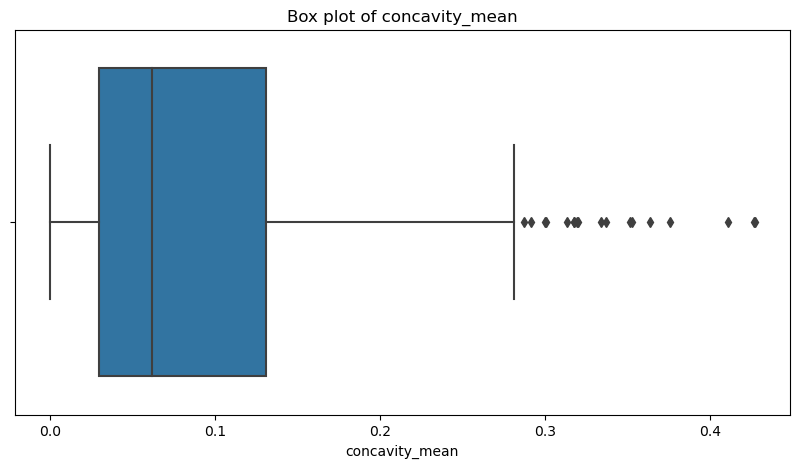

Outliers in concave points_mean:
78     0.1604
82     0.1845
108    0.1823
122    0.2012
180    0.1878
202    0.1620
212    0.1595
352    0.1913
393    0.1562
461    0.1689
Name: concave points_mean, dtype: float64


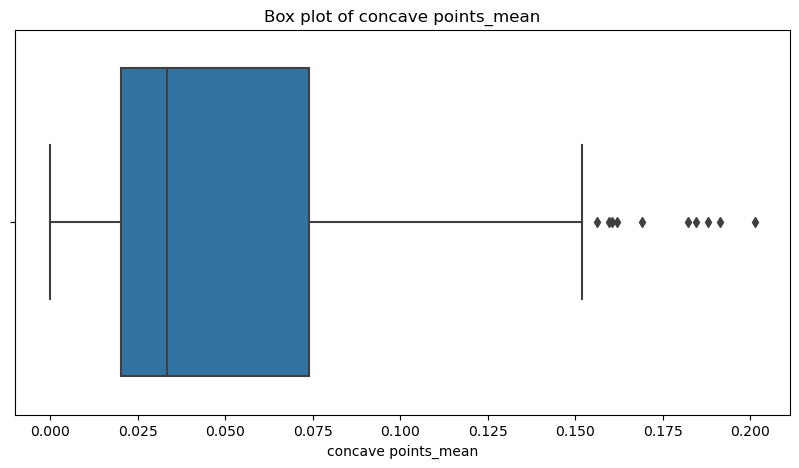

Outliers in symmetry_mean:
3      0.2597
22     0.2521
25     0.3040
60     0.2743
78     0.2906
108    0.2556
122    0.2655
146    0.2678
150    0.2540
152    0.2548
258    0.2495
288    0.2595
323    0.2569
424    0.2538
561    0.1060
Name: symmetry_mean, dtype: float64


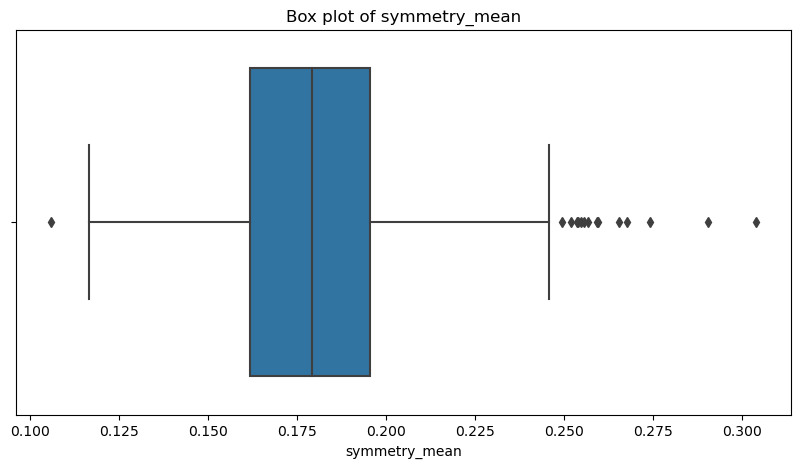

Outliers in fractal_dimension_mean:
3      0.09744
9      0.08243
68     0.08046
71     0.08980
78     0.08142
151    0.08261
152    0.09296
176    0.08116
258    0.08104
318    0.08743
376    0.08450
379    0.07950
504    0.09502
505    0.09575
507    0.07976
Name: fractal_dimension_mean, dtype: float64


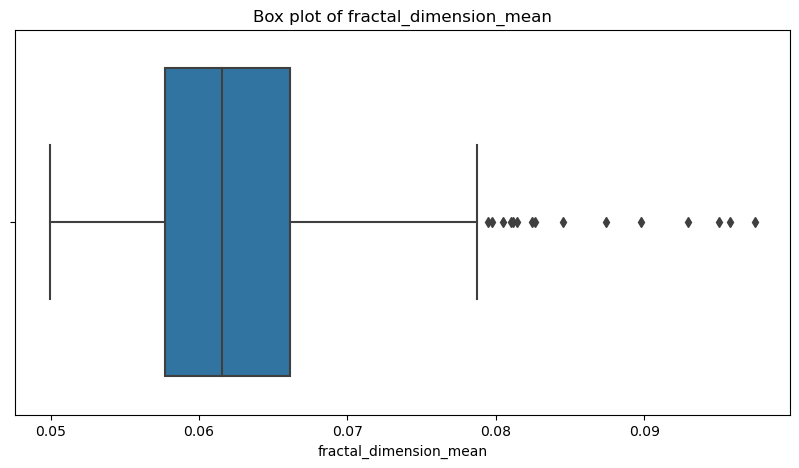

Outliers in radius_se:
0      1.0950
12     0.9555
25     1.0460
27     0.8529
38     1.2140
42     0.9811
77     0.9806
78     0.9317
82     0.8973
108    1.2150
122    1.5090
138    1.2960
161    1.0000
168    1.0880
210    0.8601
212    2.8730
218    0.9553
236    1.0580
250    1.0040
258    1.2920
265    1.1720
272    1.1670
290    0.8811
300    1.1110
302    1.0720
339    1.0090
352    0.9948
366    0.9761
368    1.2070
369    1.0080
417    1.3700
460    0.9291
461    2.5470
468    0.9289
503    1.2910
521    0.9915
563    0.9622
564    1.1760
Name: radius_se, dtype: float64


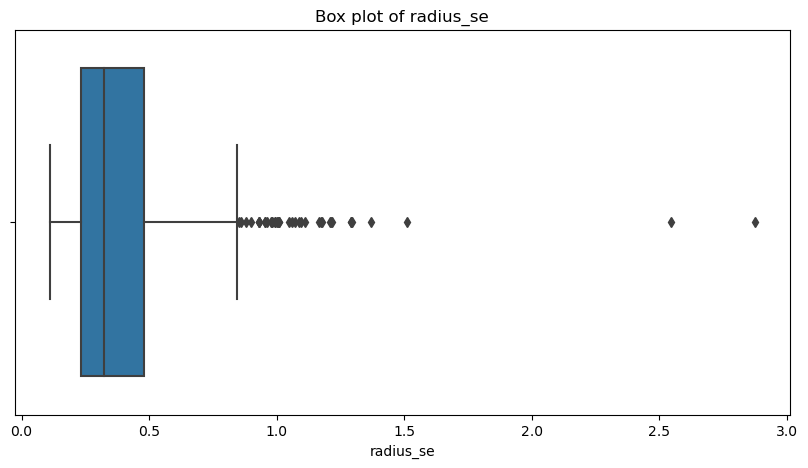

Outliers in texture_se:
12     3.568
83     2.910
122    3.120
136    2.508
152    2.664
192    4.885
245    2.612
258    2.454
314    2.777
345    2.509
389    2.836
416    2.878
443    2.542
471    2.643
473    3.647
528    2.635
557    2.927
559    2.904
561    3.896
565    2.463
Name: texture_se, dtype: float64


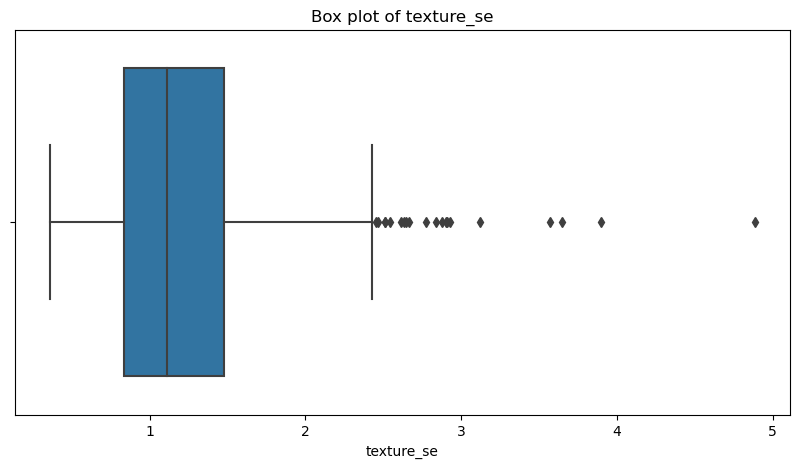

Outliers in perimeter_se:
0       8.589
12     11.070
25      7.276
38      8.077
42      8.830
77      6.311
78      8.649
82      7.382
108    10.050
122     9.807
138     8.419
161     6.971
168     7.337
210     7.029
212    21.980
218     6.487
236     7.247
250     6.372
256     7.158
258    10.120
262     6.146
265     7.749
272     8.867
300     7.237
302     7.804
335     6.076
339     6.462
352     7.222
366     7.128
368     7.733
369     7.561
417     9.424
460     6.051
461    18.650
503     9.635
521     7.050
563     8.758
564     7.673
Name: perimeter_se, dtype: float64


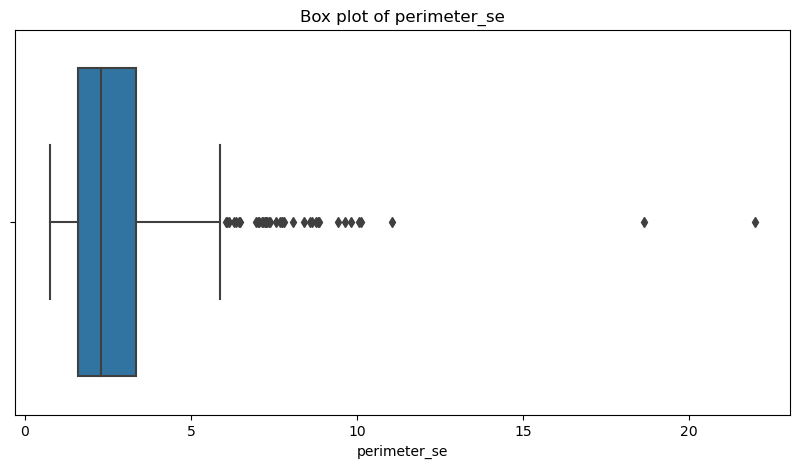

Outliers in area_se:
0      153.40
2       94.03
4       94.44
12     116.20
18     112.40
        ...  
535     87.78
563    118.80
564    158.70
565     99.04
567     86.22
Name: area_se, Length: 65, dtype: float64


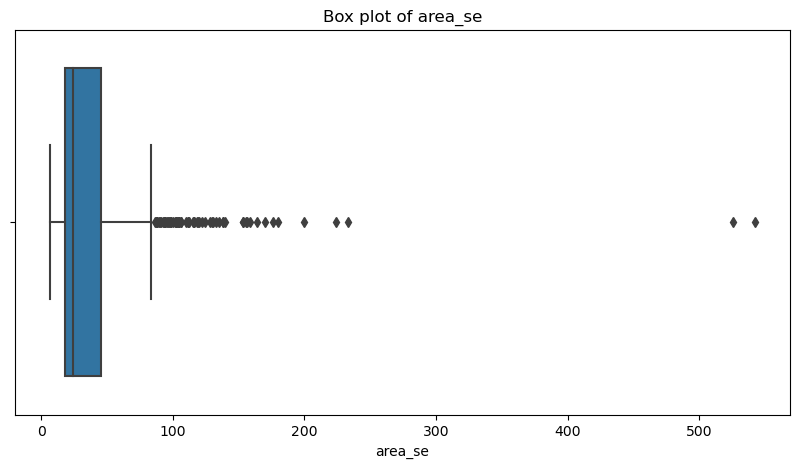

Outliers in smoothness_se:
71     0.01721
76     0.01340
110    0.01385
111    0.01291
116    0.01835
122    0.02333
173    0.01496
176    0.01286
185    0.01439
196    0.01380
212    0.01345
213    0.03113
245    0.01604
273    0.01380
275    0.01418
288    0.01574
314    0.02075
332    0.01289
345    0.01736
391    0.01582
416    0.01474
424    0.01307
469    0.01459
505    0.02177
507    0.01262
520    0.01546
537    0.01288
538    0.01266
539    0.01547
556    0.01291
Name: smoothness_se, dtype: float64


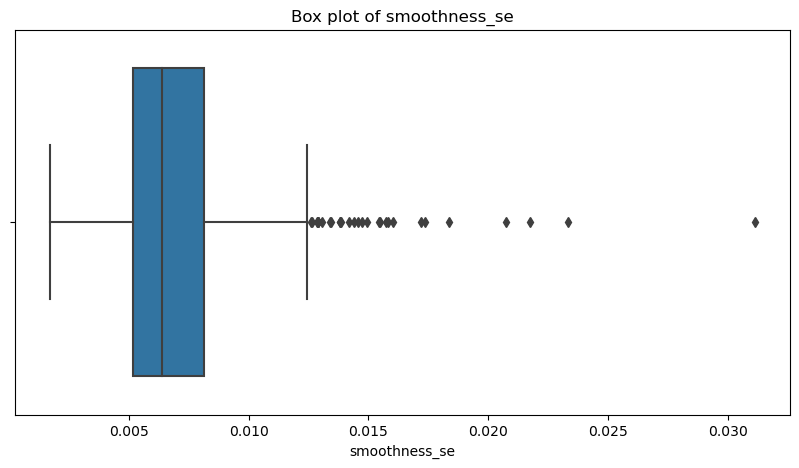

Outliers in compactness_se:
3      0.07458
9      0.07217
12     0.08297
42     0.10060
62     0.07056
68     0.08606
71     0.09368
78     0.06835
108    0.08668
112    0.07446
116    0.06760
122    0.09806
152    0.09586
176    0.08808
190    0.13540
213    0.08555
288    0.08262
290    0.10640
318    0.06590
351    0.06559
376    0.07643
388    0.06669
430    0.06213
465    0.06657
468    0.07025
485    0.07471
539    0.06457
567    0.06158
Name: compactness_se, dtype: float64


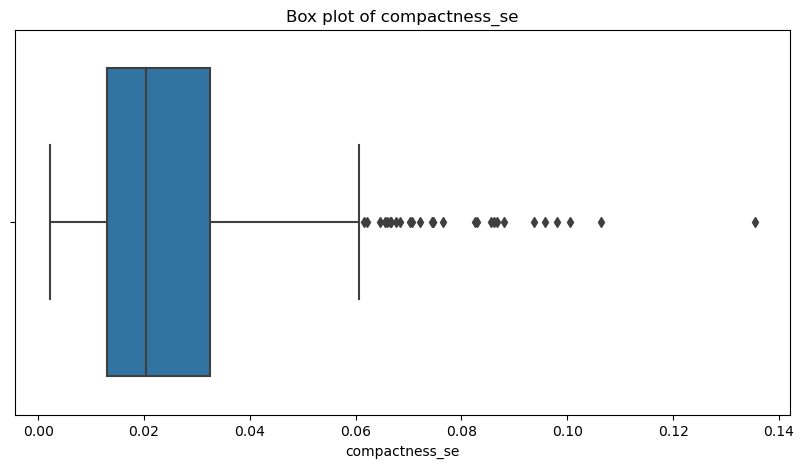

Outliers in concavity_se:
12     0.08890
42     0.09723
68     0.30380
78     0.10910
108    0.10400
112    0.14350
116    0.09263
122    0.12780
152    0.39600
176    0.11970
190    0.11660
202    0.08958
213    0.14380
242    0.08880
250    0.09518
290    0.09960
318    0.10270
351    0.09953
376    0.15350
388    0.09472
485    0.11140
539    0.09252
Name: concavity_se, dtype: float64


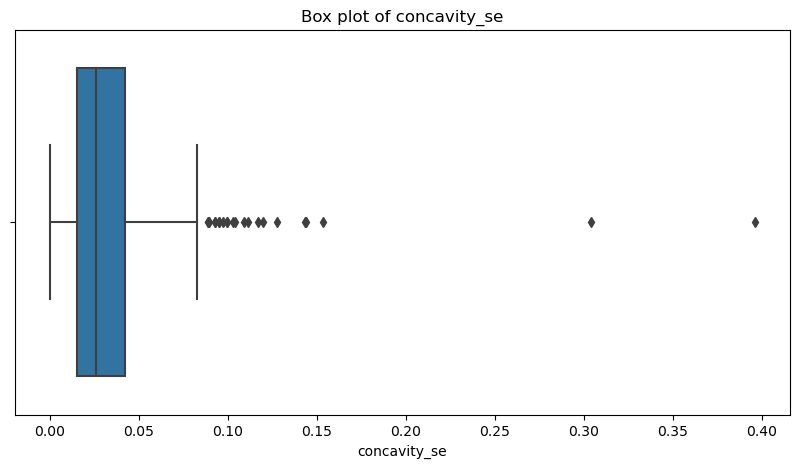

Outliers in concave points_se:
12     0.04090
42     0.02638
68     0.03322
78     0.02593
138    0.02801
152    0.05279
161    0.02794
210    0.02765
213    0.03927
258    0.03024
288    0.03487
290    0.02771
366    0.02536
376    0.02919
389    0.03441
461    0.02598
485    0.02721
528    0.02853
563    0.02624
Name: concave points_se, dtype: float64


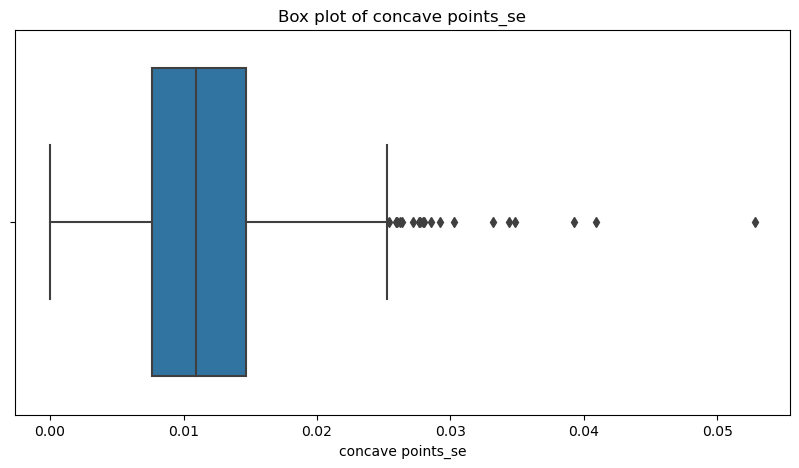

Outliers in symmetry_se:
3      0.05963
12     0.04484
22     0.03672
42     0.05333
60     0.04183
63     0.04192
68     0.04197
78     0.07895
119    0.05014
122    0.04547
138    0.05168
146    0.05628
176    0.03880
190    0.05113
192    0.03799
212    0.04783
214    0.04499
290    0.04077
314    0.06146
329    0.04022
332    0.04243
343    0.03756
345    0.03675
351    0.05543
366    0.03710
520    0.03997
553    0.03759
Name: symmetry_se, dtype: float64


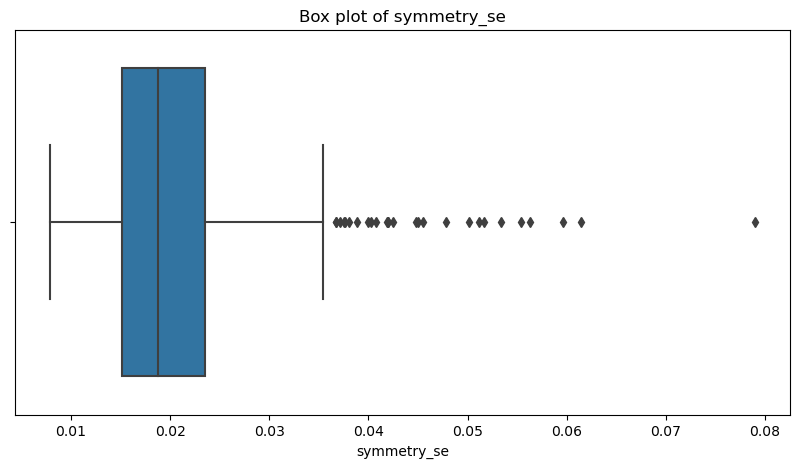

Outliers in fractal_dimension_se:
3      0.009208
9      0.010080
12     0.012840
14     0.008093
68     0.009559
71     0.021930
83     0.010390
112    0.012980
122    0.009875
145    0.009423
147    0.009368
151    0.011780
152    0.029840
176    0.017920
190    0.011720
213    0.012560
242    0.008675
257    0.008660
290    0.022860
376    0.012200
388    0.012330
450    0.008925
465    0.008133
468    0.011300
485    0.009627
504    0.010450
505    0.011480
507    0.008313
Name: fractal_dimension_se, dtype: float64


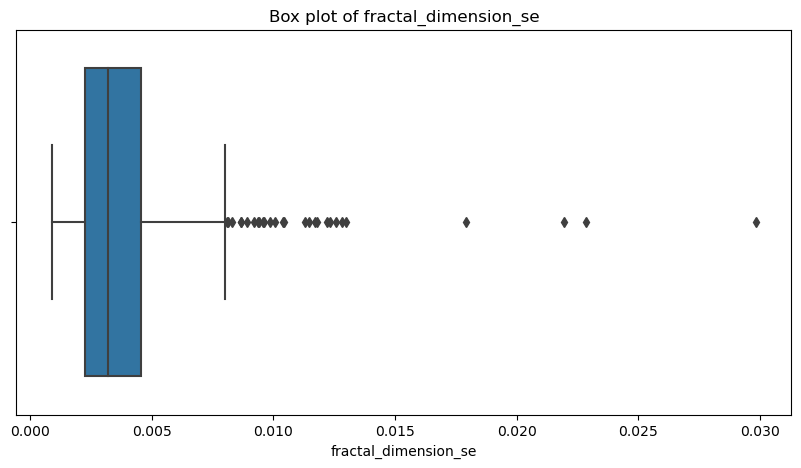

Outliers in radius_worst:
23     29.17
82     30.00
108    28.40
164    28.01
180    33.12
212    28.11
219    27.90
236    31.01
265    32.49
272    28.19
339    30.67
352    33.13
368    30.75
369    27.66
461    36.04
503    30.79
521    29.92
Name: radius_worst, dtype: float64


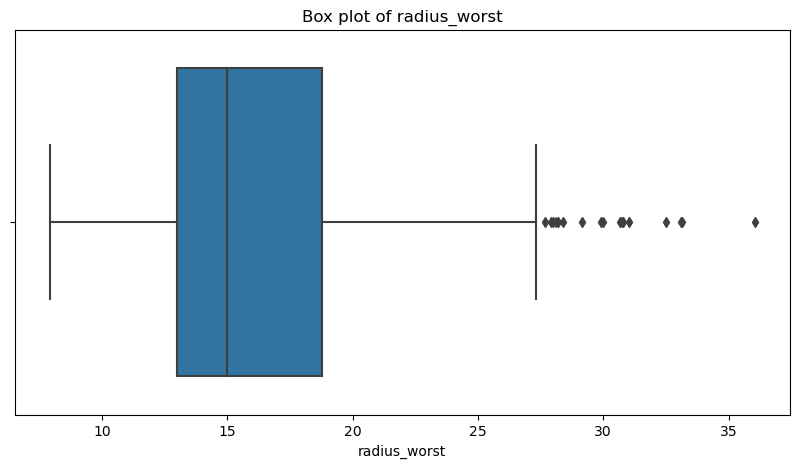

Outliers in texture_worst:
219    45.41
239    44.87
259    49.54
265    47.16
562    42.79
Name: texture_worst, dtype: float64


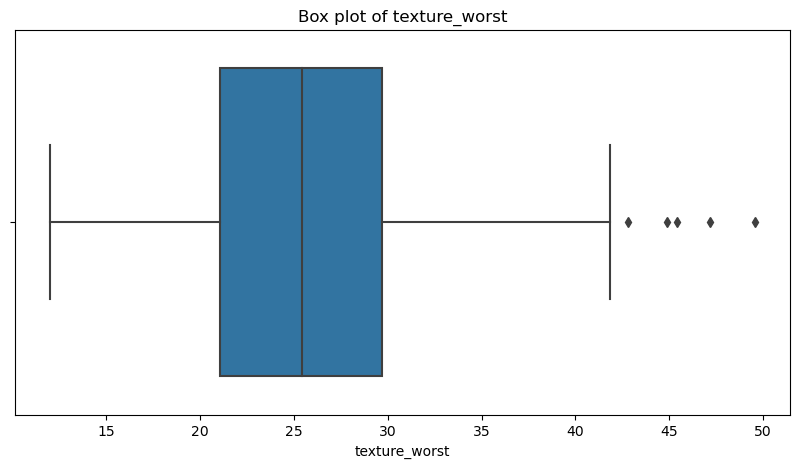

Outliers in perimeter_worst:
23     188.0
82     211.7
108    206.8
180    220.8
212    188.5
236    206.0
265    214.0
272    195.9
339    202.4
352    229.3
368    199.5
369    195.0
461    251.2
503    211.5
521    205.7
Name: perimeter_worst, dtype: float64


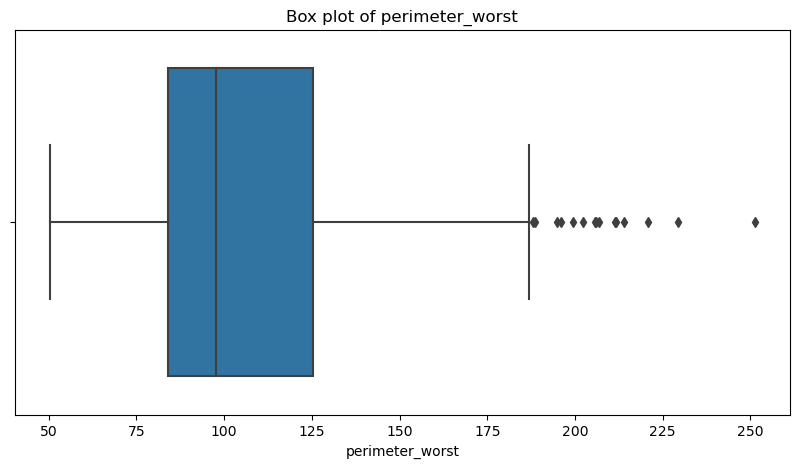

Outliers in area_worst:
0      2019.0
1      1956.0
18     2398.0
23     2615.0
24     2215.0
56     2145.0
82     2562.0
108    2360.0
122    2073.0
162    2232.0
164    2403.0
180    3216.0
181    2089.0
202    1986.0
212    2499.0
218    2009.0
219    2477.0
236    2944.0
250    2010.0
254    1972.0
265    3432.0
272    2384.0
300    2053.0
323    1938.0
339    2906.0
352    3234.0
368    3143.0
369    2227.0
373    1946.0
393    2081.0
449    2022.0
461    4254.0
503    2782.0
521    2642.0
564    2027.0
Name: area_worst, dtype: float64


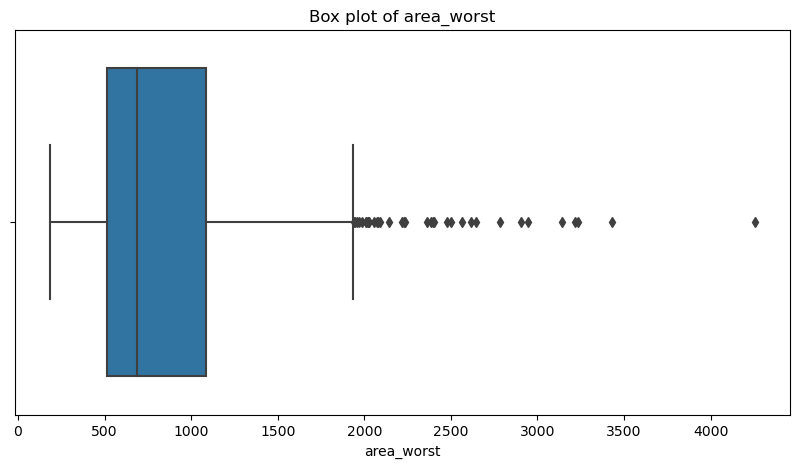

Outliers in smoothness_worst:
3      0.20980
41     0.19090
192    0.07117
203    0.22260
379    0.21840
504    0.19020
505    0.20060
Name: smoothness_worst, dtype: float64


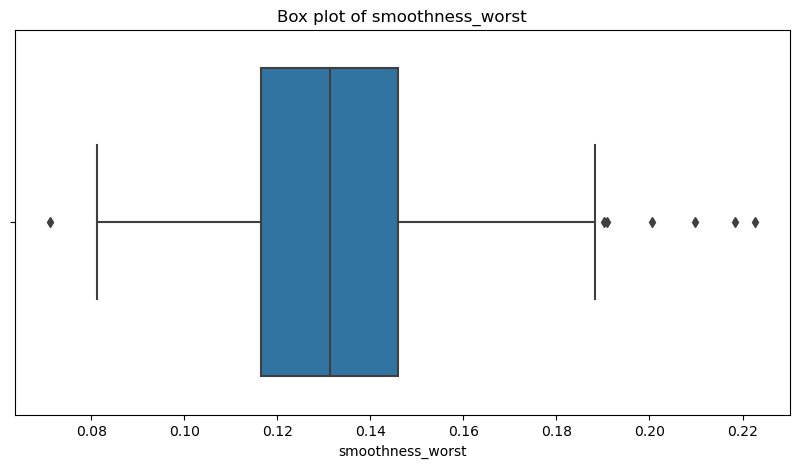

Outliers in compactness_worst:
0      0.6656
3      0.8663
9      1.0580
14     0.7725
15     0.6577
26     0.6643
33     0.6590
42     0.7444
72     0.7394
108    0.6997
181    0.7584
190    0.9327
379    0.9379
430    0.7090
562    0.7917
567    0.8681
Name: compactness_worst, dtype: float64


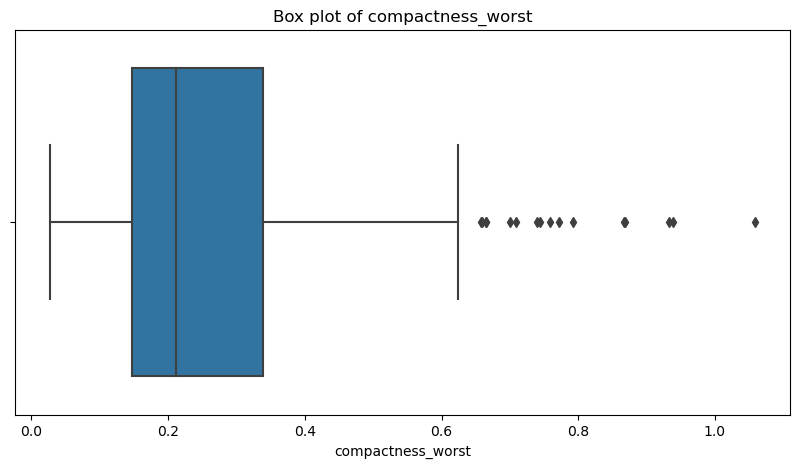

Outliers in concavity_worst:
9      1.1050
68     1.2520
108    0.9608
152    0.8216
190    0.8488
202    0.7892
252    0.8489
379    0.8402
400    0.9034
430    0.9019
562    1.1700
567    0.9387
Name: concavity_worst, dtype: float64


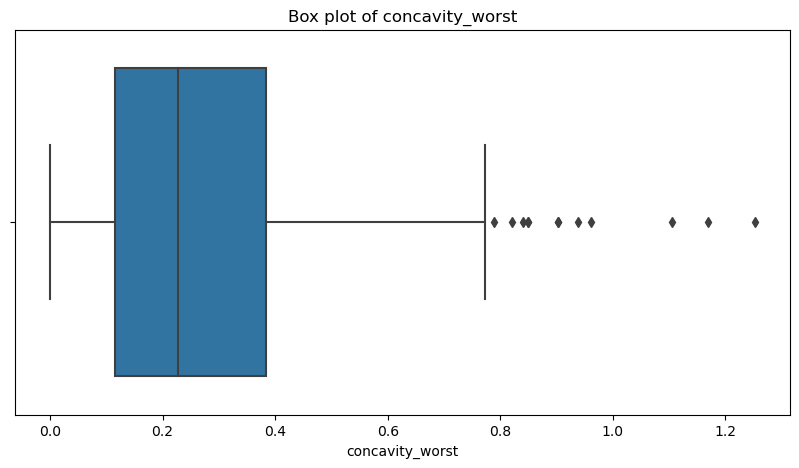

Outliers in concave points_worst:
Series([], Name: concave points_worst, dtype: float64)


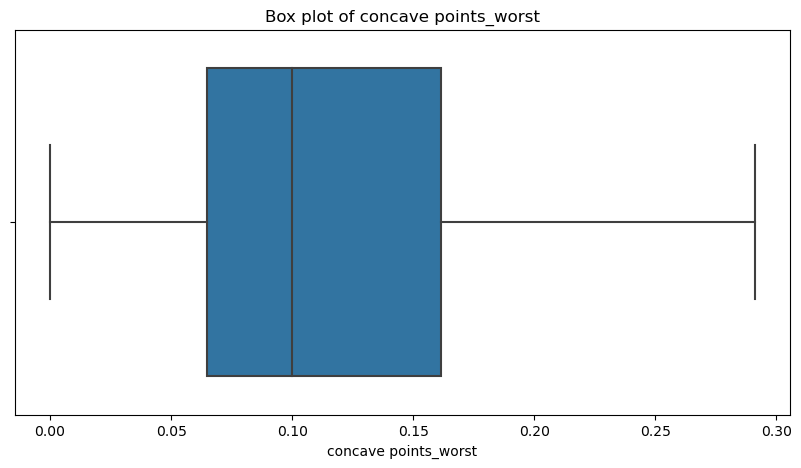

Outliers in symmetry_worst:
0      0.4601
3      0.6638
8      0.4378
9      0.4366
15     0.4218
22     0.4667
26     0.4264
31     0.4761
34     0.4270
35     0.4863
42     0.4670
68     0.4228
78     0.5440
119    0.4882
146    0.5774
190    0.5166
199    0.4753
203    0.4432
214    0.4724
323    0.5558
351    0.4245
370    0.4824
489    0.4677
Name: symmetry_worst, dtype: float64


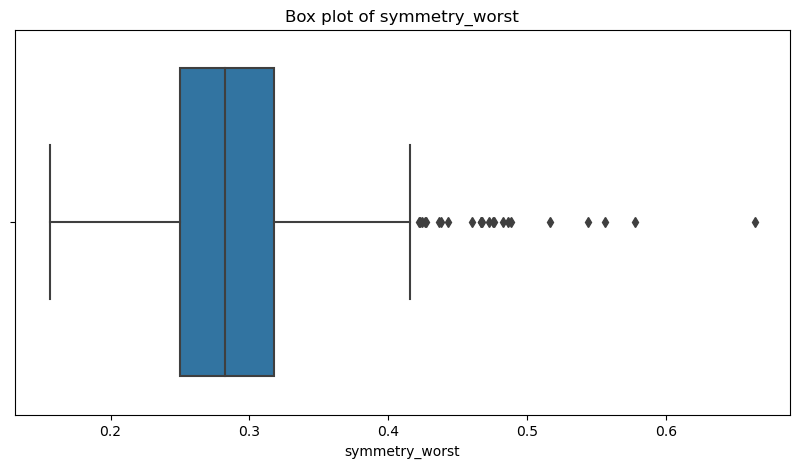

Outliers in fractal_dimension_worst:
3      0.1730
5      0.1244
9      0.2075
14     0.1431
15     0.1341
26     0.1275
31     0.1402
34     0.1233
72     0.1339
105    0.1405
118    0.1252
151    0.1486
152    0.1259
181    0.1284
190    0.1446
229    0.1243
242    0.1297
252    0.1297
379    0.1403
465    0.1249
504    0.1252
505    0.1364
562    0.1409
567    0.1240
Name: fractal_dimension_worst, dtype: float64


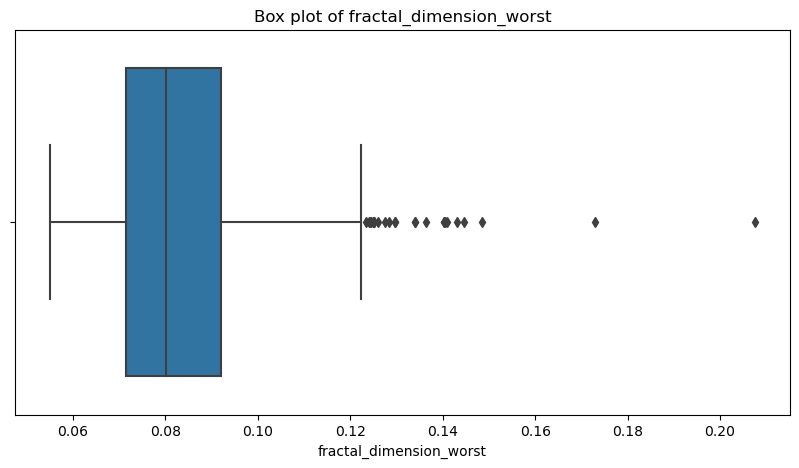

In [155]:
# To identify outlier we can use IQR Method and support that with box plot visualization.
# Numerical variable 


numerical_cols = data.select_dtypes(include=['float'])

# Function to calculate IQR and identify outliers
def identify_outliers(col):
    
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return col[(col < lower_bound) | (col > upper_bound)]

# Detecting outliers for each numerical column and plotting box plots to proof

for col in numerical_cols:
    
        outliers = identify_outliers(data[col])
        print(f"Outliers in {col}:")
        print(outliers)
        
        # Plotting box plot
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=data[col])
        plt.title(f'Box plot of {col}')
        plt.show()

# Removing Outliers

In [74]:
# Numerical variables
numerical_cols = data.select_dtypes(include=['float'])

# Column to exclude
exclude_column = 'diagnosis'

# Filter out the column to exclude
numerical_cols = [col for col in numerical_cols.columns if col != exclude_column]

# Identify and Remove Outliers
def remove_outliers(data, col):

    Q1 = data[col].quantile(0.20)
    Q3 = data[col].quantile(0.70)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]


for col in numerical_cols:

        data = remove_outliers(data, col)
        print(f'Removed outliers for columns {col} succefully')

Removed outliers for columns radius_mean succefully
Removed outliers for columns texture_mean succefully
Removed outliers for columns perimeter_mean succefully
Removed outliers for columns area_mean succefully
Removed outliers for columns smoothness_mean succefully
Removed outliers for columns compactness_mean succefully
Removed outliers for columns concavity_mean succefully
Removed outliers for columns concave points_mean succefully
Removed outliers for columns symmetry_mean succefully
Removed outliers for columns fractal_dimension_mean succefully
Removed outliers for columns radius_se succefully
Removed outliers for columns texture_se succefully
Removed outliers for columns perimeter_se succefully
Removed outliers for columns area_se succefully
Removed outliers for columns smoothness_se succefully
Removed outliers for columns compactness_se succefully
Removed outliers for columns concavity_se succefully
Removed outliers for columns concave points_se succefully
Removed outliers for co

We visualize

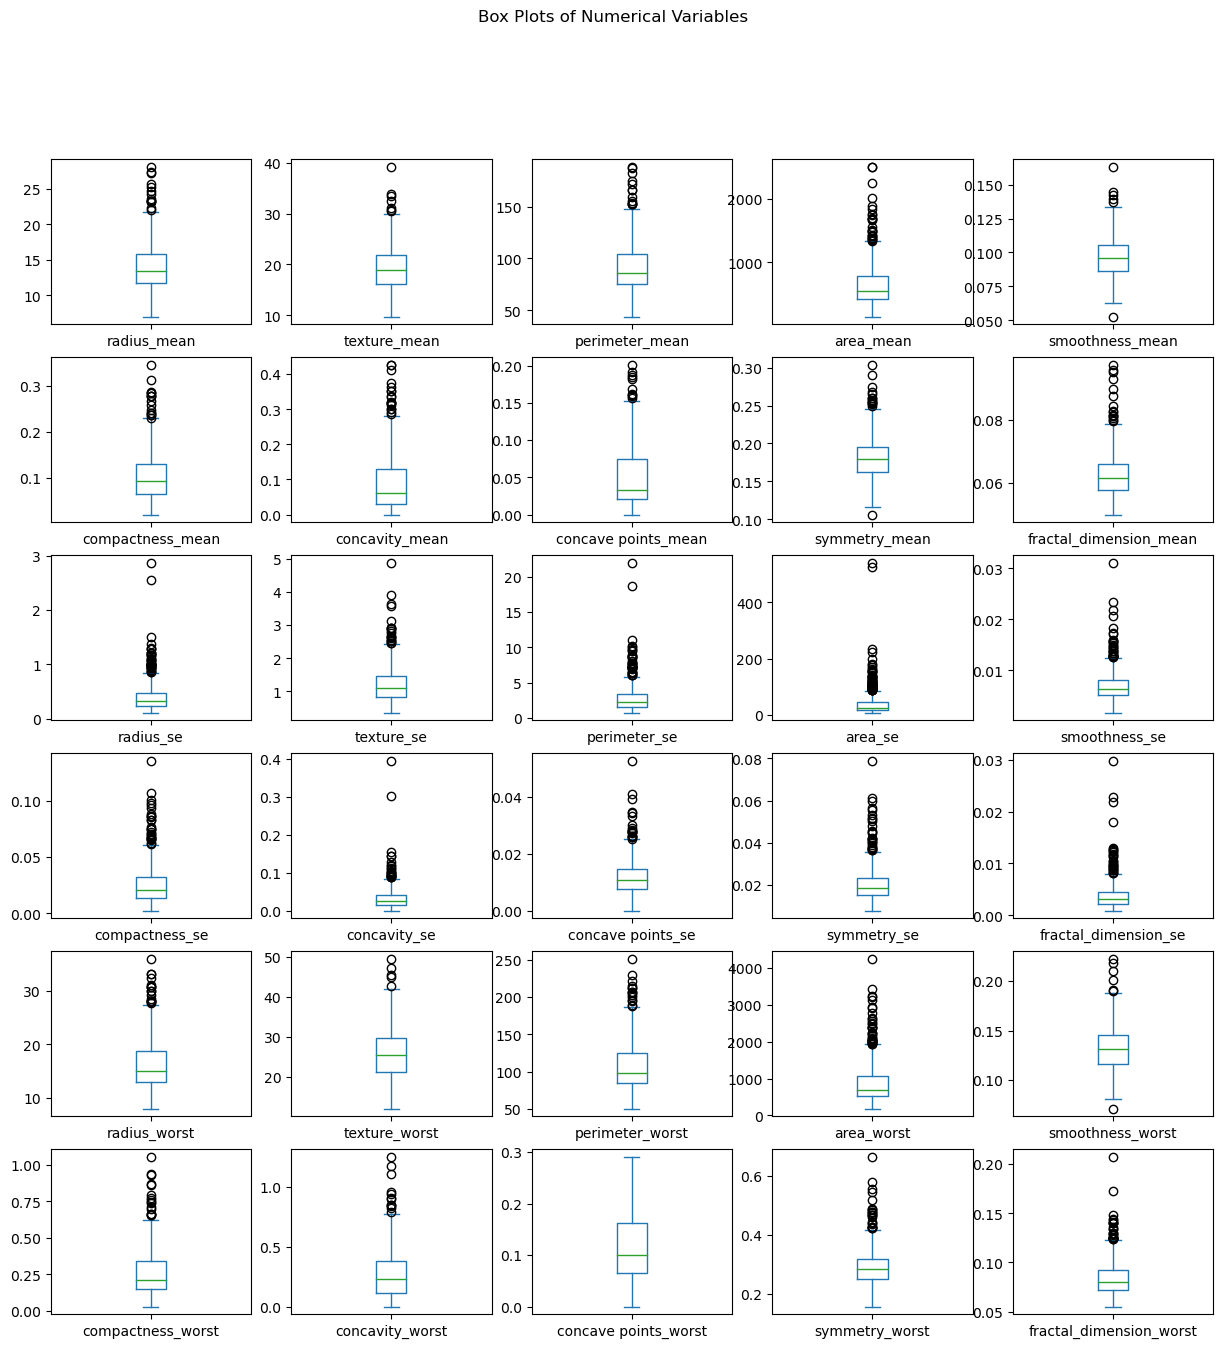

In [156]:
data[['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']
           ].plot(kind='box', subplots=True, layout=(6, 5), figsize=(15, 15), title='Box Plots of Numerical Variables')

plt.show()

**3. Just by visualizing the point clouds of the variables (you don’t have to calculate), do you see
a correlation between variables? Indicate the pairs of variables in question.**


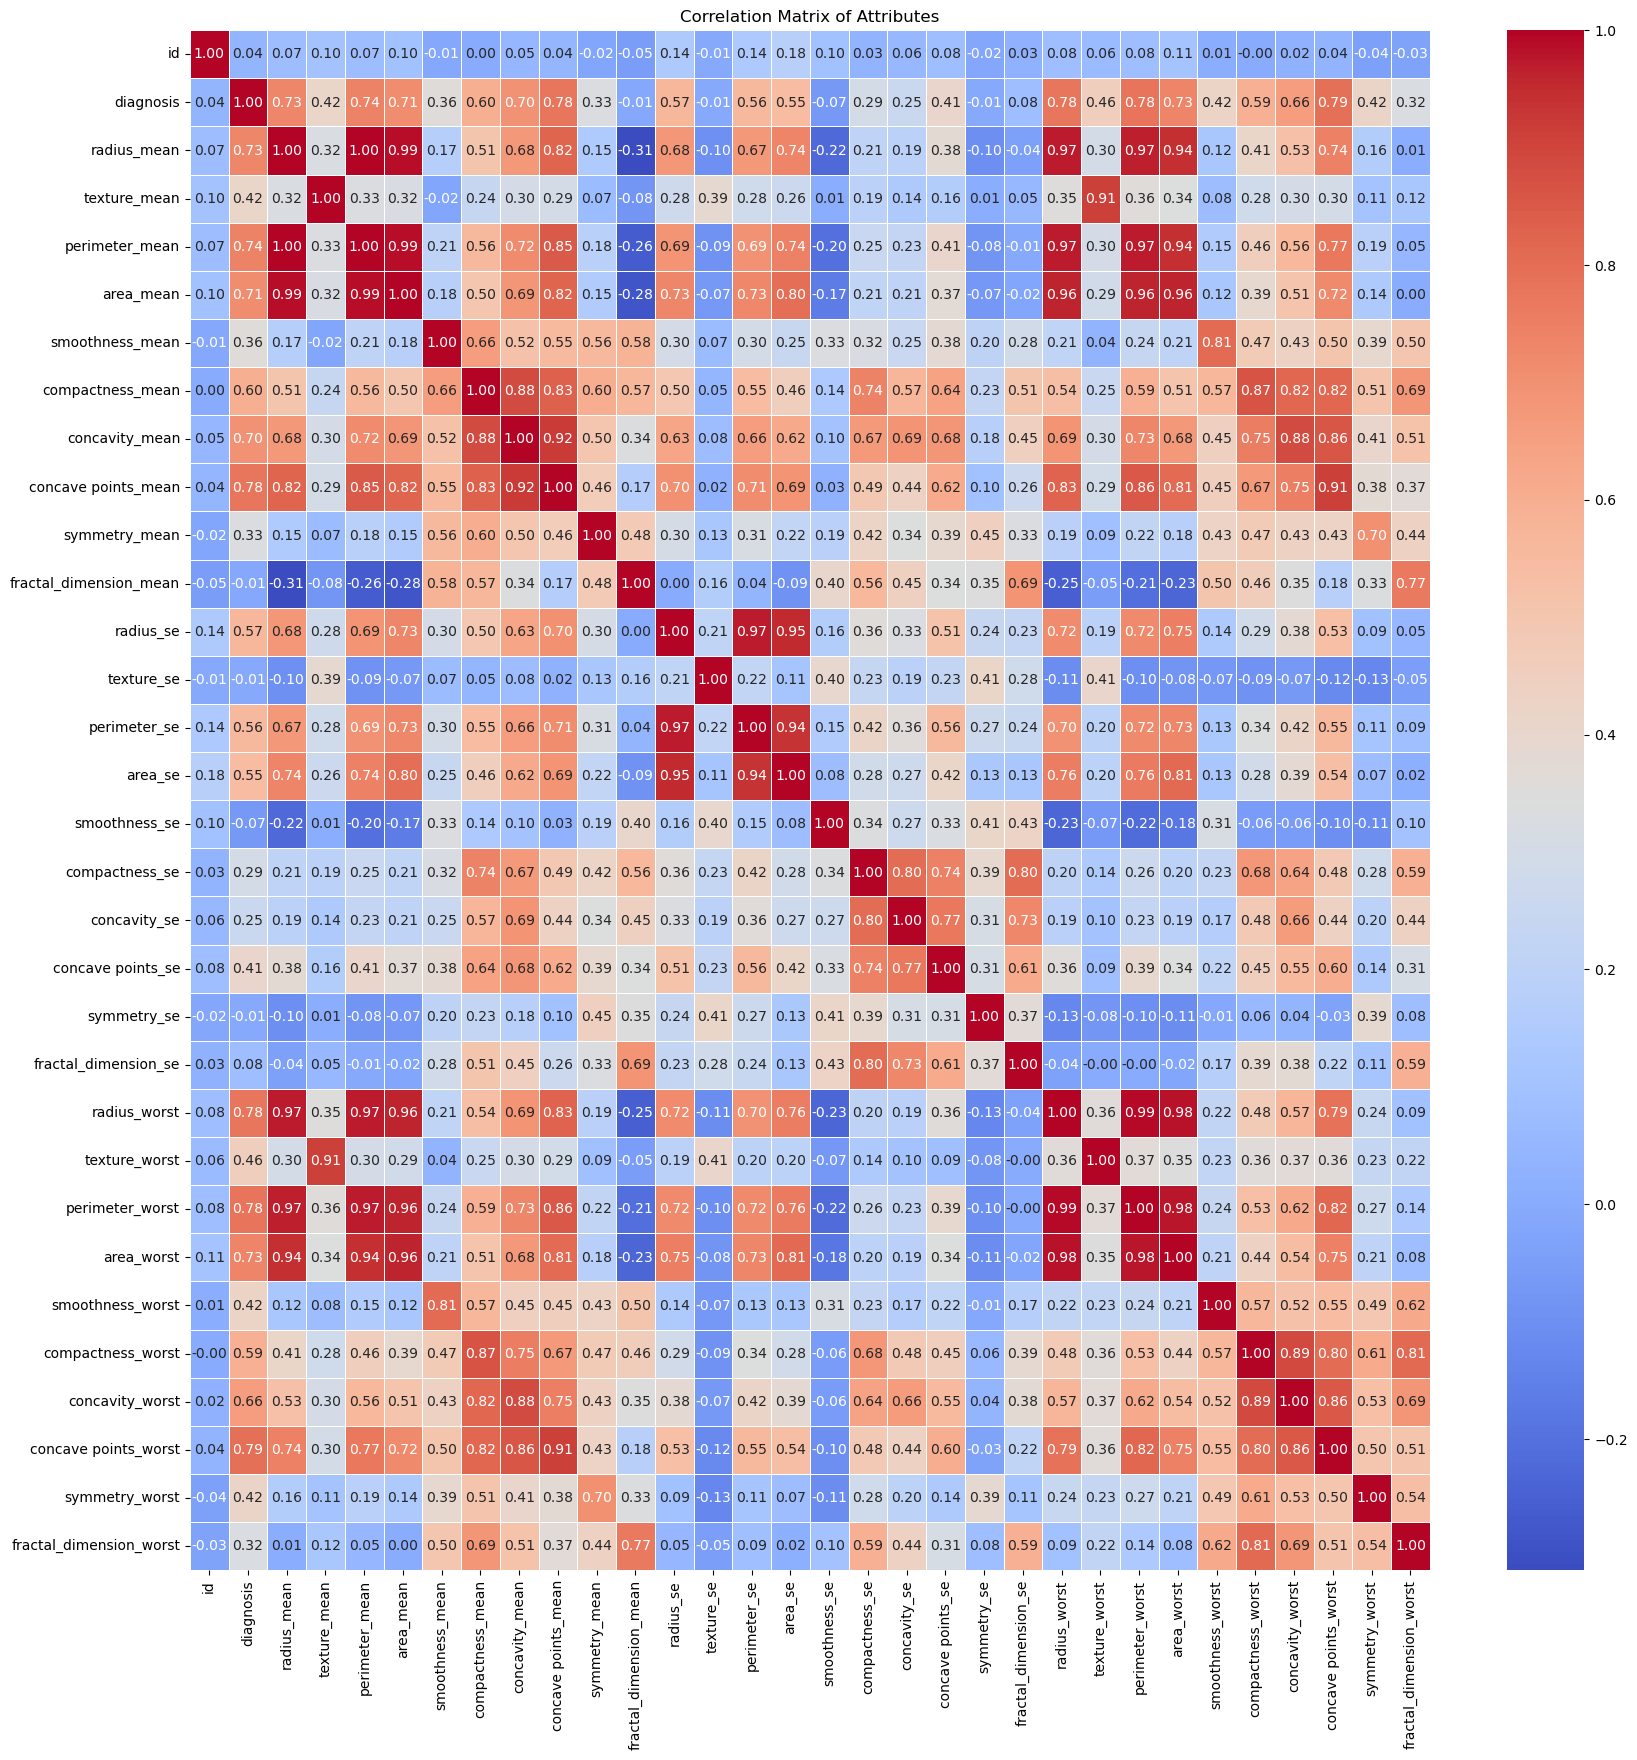

In [157]:
#Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 20))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Attributes')
plt.show()

Yes there are considerable pairs of variables with correlations such as shown below

In [158]:
# Calculate the correlation matrix
corr_matrix = data.corr()

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find unique pairs of features with correlation > 0.5 or < -0.5, excluding correlations of 1 and -1
high_corr_pairs = [(col, idx, corr_matrix.loc[col, idx]) 
                   for col in upper_triangle.columns 
                   for idx in upper_triangle.index 
                   if (upper_triangle.loc[idx, col] > 0.5 or upper_triangle.loc[idx, col] < -0.5) 
                   and upper_triangle.loc[idx, col] != 1 and upper_triangle.loc[idx, col] != -1]

# List the pairs
print("Unique pairs of variables with correlation > 0.5 or < -0.5, excluding correlations of 1 and -1:")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: {pair[2]:.2f}")

Unique pairs of variables with correlation > 0.5 or < -0.5, excluding correlations of 1 and -1:
radius_mean and diagnosis: 0.73
perimeter_mean and diagnosis: 0.74
perimeter_mean and radius_mean: 1.00
area_mean and diagnosis: 0.71
area_mean and radius_mean: 0.99
area_mean and perimeter_mean: 0.99
compactness_mean and diagnosis: 0.60
compactness_mean and radius_mean: 0.51
compactness_mean and perimeter_mean: 0.56
compactness_mean and smoothness_mean: 0.66
concavity_mean and diagnosis: 0.70
concavity_mean and radius_mean: 0.68
concavity_mean and perimeter_mean: 0.72
concavity_mean and area_mean: 0.69
concavity_mean and smoothness_mean: 0.52
concavity_mean and compactness_mean: 0.88
concave points_mean and diagnosis: 0.78
concave points_mean and radius_mean: 0.82
concave points_mean and perimeter_mean: 0.85
concave points_mean and area_mean: 0.82
concave points_mean and smoothness_mean: 0.55
concave points_mean and compactness_mean: 0.83
concave points_mean and concavity_mean: 0.92
symmetr

**4. Now look at the variable ’id’. Is it convenient to use this variable? If you consider taking any
action, indicate which one.**


No it is not convinient to use it in any of our analysis. I will consider droping it.

**5. Now analyze the ’diagnosis’ variable, which would be the object of our study (predicting whether
it is a benign or malignant case). What’s the problem with putting it in any algorithm? What
solution are you going to adopt?**

Had already converted it into binary as it is our target variable with M=1 and B = 0

**6. Is this an unbalanced problem?**


Looking at the target variable we see that...After removing the outliers the data is highly unbalanced

In [159]:
data['diagnosis'].value_counts()

0    357
1    212
Name: diagnosis, dtype: int64

**7. Apply normalization to the dataframe and divide the available examples into 80% for training
and 20% for testing, randomly.**

In [160]:
# load sci-kit learn functions for constructing logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [161]:
data.drop(columns=['id'],inplace=True)

X = data.drop('diagnosis',axis=1)
y = data['diagnosis']

In [162]:
# Fit and the data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**8. Now apply standard logistic regression (without regularization) to obtain a first data on the
accuracy of the model. What parameters have you chosen increating the logistic regression
model?**

## Logistic Regression

The logistic regression equation is given by:

 $$ \hat{y} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n)}} \ $$ 

<div style="border:1px solid black; padding: 10px;">  <br>
    where: <br>
    \(\hat{y}\) is the predicted probability of the outcome <br>
    \(\beta_0\) is the intercept,<br>
    \(\beta_1, \beta_2, \ldots, \beta_n\) are the coefficients of the model,<br>
    \(x_1,x_2, \ldots, x_n \) are the input features.<br>
</div>

C:\Users\SAM-PC\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


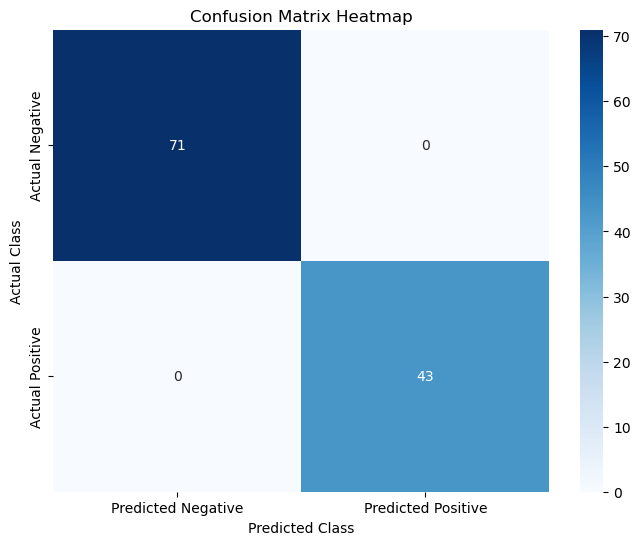

In [163]:
# Model Training using Scikit-Learn
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predictions
y_pred_class = log_reg.predict(X_test)


# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

**True Negatives (TN):** The count of observations that a classifier correctly predicted as False 71 <br>
**True Positives (TP):** The count of observations that a classifier correctly predicted as True 43 <br>
**False Positives (FP):** The count of observations that a classifier incorrectly predicted as True 0 <br>
**False Negatives (FN):** The count of observations that a classifier incorrectly predicted as False 00 <br>

# Classification Report

In [164]:
# Display Classification Report for additional metrics

print("Classification Report:")
print(classification_report(y_test, y_pred_class))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        43

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

